<a href="https://colab.research.google.com/github/genaiconference/Agentic_KAG_Workshop_DHS_2026/blob/main/03_1_text2cypher_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/genaiconference/Agentic_KAG_Workshop_DHS_2026/blob/main/08_text2cypher_workshop_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 Text2Cypher — Talking to your Knowledge Graph in Plain English

This workshop demo explores **Text2Cypher**: the process of translating a natural-language question into a **Cypher** query that a Large Language Model (LLM) can generate, validate, and execute against a Neo4j knowledge graph.

We will cover:

1. **What is Cypher, and how does it help?**
2. **What is Text2Cypher, and when should you use it?**
3. **Method 1** — Text2Cypher with **LangChain + Neo4j** (`GraphCypherQAChain`).
4. **Method 2** — Text2Cypher using **MCP** (Model Context Protocol) servers in a **ReAct agent**.

> 📖 Reference: [Neo4j — Text2Cypher Guide](https://neo4j.com/blog/genai/text2cypher-guide/)

## 🗺️ What This Notebook Covers — At a Glance

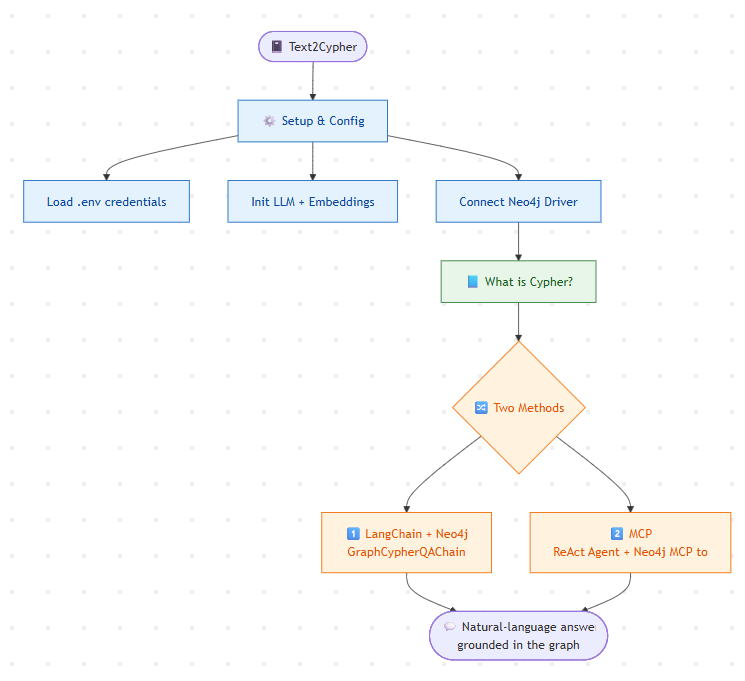

# Setup & Pre-Requisites


In [ ]:
!git clone https://github.com/genaiconference/Agentic_KAG_Workshop_DHS_2026.git

Cloning into 'Agentic_KAG_Workshop_DHS_2026'...
remote: Enumerating objects: 315, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 315 (delta 73), reused 57 (delta 55), pack-reused 224 (from 2)
Receiving objects: 100% (315/315), 11.12 MiB | 16.77 MiB/s, done.
Resolving deltas: 100% (165/165), done.


## Install Required Packages

In addition to the workshop requirements, we install the LangChain-Neo4j integration and the MCP adapters used in the two methods below.

In [1]:
!pip install -r /content/Agentic_KAG_Workshop_DHS_2026/requirements.txt --quiet
!pip install -U --upgrade-strategy eager "mcp>=1.12.0" "langchain-mcp-adapters>=0.1.0" --quiet
!pip install langchain-neo4j langchain-openai langgraph --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.5/182.5 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 2.4.0 requires opentelemetry-api<=1.42.1,>=1.39, but you have opentelemetry-api 1.44.0 which is incompatible.
google-adk 2.4.0 requires opentelemetry-sdk<=1.42.1,>=1.39, but you have opentelemetry-sdk 1.44.0 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-genai 2.11.0 requires websockets<17.0,>=13.0.0, but you have websockets 17.0.1 which is incompatible.
langgraph-sdk 0.4.2 requires websockets<16,>=14, but you have websockets 17.0.1 which is incompatible.
google-adk 2.4.0 requires opentelemetry-api<=1.42.1,>=1.39, but you have opentelemetry-api 1.44.0 which is incompati

## Credentials & Drivers
The Neo4j driver allows you to connect and perform read and write transactions with the database.

In [5]:
import os

os.chdir('/content/Agentic_KAG_Workshop_DHS_2026/')

try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    print("error reading env details")
    pass

# --- Neo4j Sandbox ---
NEO4J_URI      = os.getenv('NEO4J_URI')
NEO4J_USERNAME = os.getenv('NEO4J_USERNAME')
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD')
NEO4J_DATABASE = os.getenv('NEO4J_DATABASE') or 'neo4j'

# --- OpenAI ---
os.environ.setdefault(
    'OPENAI_API_KEY',
    os.getenv('OPENAI_API_KEY')
)

print('NEO4J_URI :', NEO4J_URI)
print('OPENAI key set:', bool(os.environ.get('OPENAI_API_KEY')))

NEO4J_URI : bolt://44.204.116.51
OPENAI key set: True


## Connect to the existing movie graph

In [3]:
from neo4j import GraphDatabase

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))
driver.verify_connectivity()
print('Connected to Neo4j ✔')

Connected to Neo4j ✔


## Initialize LLM and Embeddings

We use OpenAI **GPT-5-mini** for generation and **text-embedding-3-small** for embeddings — identical to notebook 03. For the LangChain and MCP methods we use the `langchain-openai` `ChatOpenAI` wrapper so the model plugs into chains and agents.

In [4]:
# neo4j-graphrag primitives (same as notebook 03)
from neo4j_graphrag.llm import OpenAILLM
from neo4j_graphrag.embeddings import OpenAIEmbeddings

llm = OpenAILLM(model_name="gpt-5-mini")
embedder = OpenAIEmbeddings(model="text-embedding-3-small")

# LangChain chat model (used by GraphCypherQAChain and the ReAct agent)
from langchain_openai import ChatOpenAI

chat_llm = ChatOpenAI(model="gpt-5-mini", temperature=0)
print('LLM + embeddings ready ✔')

LLM + embeddings ready ✔


---
# 📘 What is Cypher? And how does it help?

**Cypher** is Neo4j's declarative graph query language — think of it as *“SQL for graphs”*. Instead of joining tables, you describe **patterns** of nodes and relationships using an intuitive, ASCII-art-like syntax:

```cypher
MATCH (p:Person)-[l:LIVES_AT]->(a:Address)
WHERE p.name = "Bob" AND l.since >= date('2025-01-01')
RETURN a.address AS address
```

- `()` → **nodes** (with labels like `:Person`, `:Address`)
- `-[]->` → **relationships** (with types like `:LIVES_AT`, and a direction)
- `WHERE` → **filters** on node/relationship properties
- `RETURN` → the data you want back

### How does it help?
- 🧠 **Expresses relationships naturally** — multi-hop traversals that would need many SQL joins become a single readable pattern.
- ⚡ **Fast graph traversals** — built for connected data (recommendations, fraud rings, knowledge graphs).
- 🔍 **Precise & deterministic** — unlike pure vector search, Cypher answers exact, structured questions (counts, aggregations, filters, shortest paths).

### The challenge 😅
Business users and analysts rarely know Cypher. **Text2Cypher** bridges that gap: an LLM translates a plain-English question into a Cypher query, runs it, and returns a grounded answer.

## The Text2Cypher Workflow

A robust Text2Cypher implementation follows this loop (from the Neo4j guide):

1. The agent **fetches the graph schema** via a tool call.
2. If more information is needed, it iteratively calls other tools until a query can be written.
3. The LLM **generates a Cypher query** using the user question + schema (+ any extra context) as context.
4. The query is **validated** and corrected (by code or LLM).
5. The validated query is **executed** against the database.
6. Any **errors are analysed** and the query is corrected → validated → re-executed (this loop may repeat).
7. On success, the **results feed back** into the context and the agent continues.

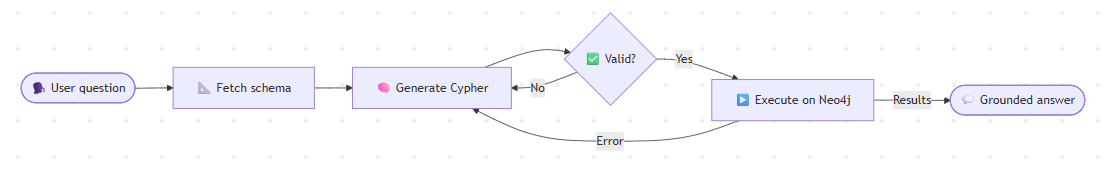

We'll now see **two practical ways** to implement this.

---
# 1️⃣ Method 1 — Text2Cypher with LangChain + Neo4j

The [`langchain-neo4j`](https://docs.langchain.com/oss/python/integrations/graphs/neo4j_cypher) library provides the **`GraphCypherQAChain`** class — a ready-made abstraction for the whole Text2Cypher workflow. It:

- automatically retrieves and formats the **graph schema**,
- prompts the LLM to **generate Cypher**,
- includes a **validation–correction layer** (`CypherQueryCorrector`) that detects reversed relationship directions and fixes them against the schema,
- **executes** the query and passes results to a second LLM call to write the final answer,
- integrates cleanly with the rest of the LangChain / LangGraph ecosystem.

First, we wrap our Neo4j database with the LangChain `Neo4jGraph` object, which exposes the schema to the chain.

In [5]:
from langchain_neo4j import Neo4jGraph
from IPython.display import Markdown

graph = Neo4jGraph(
    url=NEO4J_URI,
    username=NEO4J_USERNAME,
    password=NEO4J_PASSWORD,
    database=NEO4J_DATABASE,
    enhanced_schema=True,   # richer schema (property types, example values) improves generation
)

# Refresh + inspect the schema the LLM will use as context
graph.refresh_schema()
Markdown(graph.schema)

Node properties:
- **Movie**
  - `revenue_usd`: INTEGER Min: 2100000, Max: 683241751
  - `runtime_minutes`: INTEGER Min: 109, Max: 190
  - `overview`: STRING Example: "The Eternals are a team of ancient aliens who have"
  - `release_date`: STRING Example: "2021-11-03"
  - `vote_average`: FLOAT Min: 2.88, Max: 8.442
  - `budget_usd`: INTEGER Min: 10000000, Max: 200000000
  - `tagline`: STRING Example: "In the beginning..."
  - `title`: STRING Example: "Eternals"
  - `name`: STRING Available options: ['Remo']
- **Person**
  - `name`: STRING Example: "Chloé Zhao"
  - `character`: STRING Available options: ['Muthanna', 'Vidya Sinha', 'Shyam']
- **Genre**
  - `name`: STRING Example: "Science Fiction"
- **ProductionCompany**
  - `name`: STRING Example: "Marvel Studios"
- **Country**
  - `name`: STRING Example: "Canada"
- **Language**
  - `name`: STRING Example: "Arabic"
- **Keyword**
  - `name`: STRING Example: "superhero"
Relationship properties:
- **DIRECTED_BY**
  - `role`: STRING Available options: ['Director', 'director']
  - `details`: STRING Example: "Director"
- **CAST_IN**
  - `details`: STRING Example: "Actor"
  - `role`: STRING Available options: ['actor', 'Bhoomi', 'Actor', 'Arun Sachdeva', 'Dhauli']
  - `character`: STRING Available options: ['Muthanna', 'Wisam Ahmad Kashmiri', 'Shivangi', 'Shyam']
- **HAS_GENRE**
  - `details`: STRING Example: "Genre"
  - `name`: STRING Available options: ['Action', 'Crime']
- **PRODUCED_BY**
  - `details`: STRING Example: "Production company"
  - `name`: STRING Available options: ['Prabhu Deva Studios']
- **PRODUCED_IN**
  - `details`: STRING Example: "Production country"
  - `name`: STRING Available options: ['India']
- **SPOKEN_IN**
  - `details`: STRING Example: "Spoken language"
  - `name`: STRING Available options: ['Tamil']
- **TAGGED_WITH**
  - `details`: STRING Example: "Keyword/tag"
  - `name`: STRING Available options: ['body-swap', 'ancient knowledge']
The relationships:
(:Movie)-[:DIRECTED_BY]->(:Person)
(:Movie)-[:HAS_GENRE]->(:Genre)
(:Movie)-[:PRODUCED_BY]->(:ProductionCompany)
(:Movie)-[:PRODUCED_IN]->(:Country)
(:Movie)-[:SPOKEN_IN]->(:Language)
(:Movie)-[:TAGGED_WITH]->(:Keyword)
(:Person)-[:CAST_IN]->(:Movie)

### Build the `GraphCypherQAChain`

> ⚠️ `allow_dangerous_requests=True` is required because generated Cypher runs directly against the database. In production, connect using a **read-only** Neo4j user so the LLM can never issue write/delete queries.

> Combine graph connector, llm connector and prompt template (below) to create the chain that will handle Text2Cypher process

In [ ]:
from langchain_neo4j import GraphCypherQAChain
from langchain_core.prompts.prompt import PromptTemplate

CYPHER_GENERATION_TEMPLATE = """Task:
Generate Cypher statement to query a graph database.

Instructions:
Use only the provided relationship types and properties in the schema.
Do not use any other relationship types or properties that are not provided.

Schema:
{schema}

Note: Do not include any explanations or apologies in your responses.
Do not respond to any questions that might ask anything else than for you to construct a Cypher statement.
Do not include any text except the generated Cypher statement.

Examples: Here are a few examples of generated Cypher statements for particular questions:
# How many people played in Top Gun?
MATCH (m:Movie {{name:"Top Gun"}})<-[:ACTED_IN]-()
RETURN count(*) AS numberOfActors

The question is:
{question}"""

CYPHER_GENERATION_PROMPT = PromptTemplate(
    input_variables=["schema", "question"], template=CYPHER_GENERATION_TEMPLATE
)

chain = GraphCypherQAChain.from_llm(
    llm=chat_llm,
    graph=graph,
    verbose=True,                 # print the generated Cypher + intermediate steps
    cypher_prompt=CYPHER_GENERATION_PROMPT,
    return_intermediate_steps=True,
    allow_dangerous_requests=True,
)
print('GraphCypherQAChain ready ✔')

GraphCypherQAChain ready ✔


### Ask a question in plain English

Watch the `verbose` output: the chain prints the **generated Cypher query**, the **raw results**, and then the **final natural-language answer**.

In [ ]:
result = chain.invoke({"query": "List the top 10 highest-rated Hindi movies"})

print("\n=== Generated Cypher ===")
for step in result.get("intermediate_steps", []):
    if "query" in step:
        print(step["query"])

print("\n=== Final Answer ===")
print(result["result"])



> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (m:Movie)-[:SPOKEN_IN]->(lang:Language {name: "Hindi"})
RETURN m.title AS title, m.vote_average AS rating
ORDER BY m.vote_average DESC
LIMIT 10
Full Context:
[{'title': 'Spider-Man: Across the Spider-Verse', 'rating': 8.442}, {'title': 'Sonchiriya', 'rating': 8.3}, {'title': 'Lion', 'rating': 8.083}, {'title': 'Jersey', 'rating': 8.0}, {'title': 'Sanam Teri Kasam', 'rating': 7.976}, {'title': 'Dangal', 'rating': 7.934}, {'title': 'Period. End of Sentence.', 'rating': 7.896}, {'title': 'Kammatipaadam', 'rating': 7.8}, {'title': 'Drishyam 2', 'rating': 7.788}, {'title': 'The Farthest', 'rating': 7.707}]

> Finished chain.

=== Generated Cypher ===
MATCH (m:Movie)-[:SPOKEN_IN]->(lang:Language {name: "Hindi"})
RETURN m.title AS title, m.vote_average AS rating
ORDER BY m.vote_average DESC
LIMIT 10

=== Final Answer ===
The top 10 highest-rated Hindi movies are: Spider-Man: Across the Spider-Verse (8.442), Sonchiriya (8.3),

In [17]:
for q in [
    "Which movies did S.S. Rajamouli direct?",
    "How many movies are in the graph?",
    "List down top 5 actors by highest movies",
]:
    display(Markdown(f"\n🗣️  **{q}**"))
    ans = chain.invoke({"query": q})
    print("🤖 ", ans["result"])
    print("====================================================")


🗣️  **Which movies did S.S. Rajamouli direct?**



> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (m:Movie)-[:DIRECTED_BY]->(p:Person {name: "S.S. Rajamouli"})
RETURN m.title AS title
Full Context:
[{'title': 'RRR'}, {'title': 'Bāhubali 2: The Conclusion'}]

> Finished chain.
🤖  RRR, Bāhubali 2: The Conclusion were directed by S.S. Rajamouli.



🗣️  **How many movies are in the graph?**



> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (m:Movie)
RETURN count(m) AS numberOfMovies
Full Context:
[{'numberOfMovies': 496}]

> Finished chain.
🤖  There are 496 movies in the graph.



🗣️  **List down top 5 actors by highest movies**



> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (p:Person)-[:CAST_IN]->(m:Movie)
RETURN p.name AS actor, count(DISTINCT m) AS movieCount
ORDER BY movieCount DESC
LIMIT 5
Full Context:
[{'actor': 'Prakash Raj', 'movieCount': 21}, {'actor': 'Akshay Kumar', 'movieCount': 19}, {'actor': 'Vijay Sethupathi', 'movieCount': 17}, {'actor': 'Nassar', 'movieCount': 16}, {'actor': 'Fahadh Faasil', 'movieCount': 16}]

> Finished chain.
🤖  Prakash Raj, Akshay Kumar, Vijay Sethupathi, Nassar, Fahadh Faasil are the top 5 actors by highest movies.


✅ **Method 1 takeaways**

- `GraphCypherQAChain` is the fastest way to a working Text2Cypher **proof of concept**.
- It handles schema retrieval, prompting, validation-correction, execution, and answer synthesis for you.
- Best when you want a tight, self-contained chain inside the LangChain ecosystem.

But what if you want the LLM to **decide when** to query the graph, correct its own errors iteratively, and combine graph access with other tools? That's where **MCP + a ReAct agent** shines.

---
# 2️⃣ Method 2 — Text2Cypher using MCP

The **easiest and most flexible** way to implement a Text2Cypher workflow is with the **Neo4j MCP (Model Context Protocol) servers**. You may use either:

- the [**official Neo4j MCP server**](https://github.com/neo4j/mcp) — **recommended**, supported by the Neo4j engineering team, or
- the [**Neo4j Labs Cypher MCP server**](https://github.com/neo4j-contrib/mcp-neo4j/tree/main/servers/mcp-neo4j-cypher) — supported by the AI Field Team, contains experimental features.

Both servers expose **tools for schema retrieval and Cypher execution**. They plug into agentic applications (like Claude Desktop or Cursor) or into your own custom agents. Here, the **agent-LLM is responsible for generating and executing** the Cypher using the MCP tools — following a simplified version of the Text2Cypher workflow, where **query validation happens inside the execution tool**.

> These servers are typically used in a **ReAct agent architecture** (Reason → Act → Observe → repeat).

## 🧩 What is MCP? (The Basics)

**MCP (Model Context Protocol)** is an **open standard** — introduced by Anthropic — that defines *how AI applications connect to external tools, data, and systems* in a consistent, plug-and-play way.

Think of it as the **“USB-C for AI”**: instead of writing a custom integration for every tool + every LLM app, you build to one standard and everything interoperates.

### 🤔 Why does MCP exist?
Before MCP, every AI app had to hand-roll its own connectors (one for Neo4j, one for GitHub, one for Slack…). This is the classic **"M × N problem"**: *M* AI apps × *N* tools = a lot of duplicated, brittle glue code. MCP turns this into an **"M + N"** problem — each tool exposes one MCP server, each app speaks MCP once.

### 🏗️ Core concepts

| Term | What it means |
|---|---|
| **Host** | The AI application the user interacts with (Claude Desktop, Cursor, VS Code, or a custom agent). |
| **Client** | Lives inside the host; maintains a 1:1 connection to a server. |
| **Server** | A lightweight program that exposes capabilities (e.g., the **Neo4j MCP server**). |
| **Tools** | Actions the LLM can call (e.g., `get_neo4j_schema`, `read_neo4j_cypher`). |
| **Resources** | Read-only data the server can provide (files, records, schema). |
| **Prompts** | Reusable prompt templates the server offers. |

### 🔄 How it works (simplified)

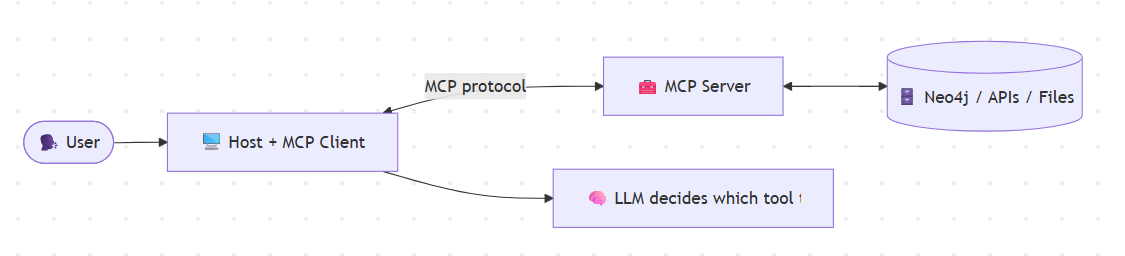

1. The host starts an MCP **server** and discovers its **tools**.
2. The **LLM** decides *which* tool to call to answer a question.
3. The **client** sends the call to the server; the server runs it (e.g., executes Cypher) and returns results.
4. The LLM uses those results to produce a grounded answer.

### ✅ Why it matters here
For Text2Cypher, the **Neo4j MCP server** exposes ready-made tools for **schema retrieval** and **Cypher execution**. Any MCP-aware agent can use them without custom code — which is exactly what we do in Method 2 below.

> 📖 Learn more: [modelcontextprotocol.io](https://modelcontextprotocol.io) · [Neo4j MCP servers](https://github.com/neo4j-contrib/mcp-neo4j)


## MCP Server Configuration

For MCP **client applications** (Claude Desktop, Cursor, VS Code), you register the server in a JSON config. Both options are shown — use the **official** server where possible:

```json
{
    "mcpServers": {
        "neo4j-labs-cypher": {
            "command": "uvx",
            "args": [ "mcp-neo4j-cypher@0.5.2", "--transport", "stdio" ],
            "env": {
                "NEO4J_URI": "bolt://localhost:7687",
                "NEO4J_USERNAME": "neo4j",
                "NEO4J_PASSWORD": "<your-password>",
                "NEO4J_DATABASE": "neo4j"
            }
        },
        "neo4j-official-mcp": {
            "type": "stdio",
            "command": "neo4j-mcp",
            "env": {
                "NEO4J_URI": "bolt://localhost:7687",
                "NEO4J_USERNAME": "neo4j",
                "NEO4J_PASSWORD": "<your-password>",
                "NEO4J_DATABASE": "neo4j"
            }
        }
    }
}
```

Below, we connect to the same MCP server **programmatically** from a custom ReAct agent.

## Build a ReAct Agent over the Neo4j MCP tools

We use **`langchain-mcp-adapters`** to launch the Neo4j Cypher MCP server as a subprocess (via `uvx`), load its tools (schema retrieval + Cypher execution), and hand them to a **LangGraph ReAct agent**. The agent will reason about the question, call `get_neo4j_schema`, generate Cypher, call `read_neo4j_cypher`, and iterate on errors — exactly the Text2Cypher workflow.

> ℹ️ The MCP client uses `asyncio`. In notebooks the event loop is already running, so we `await` coroutines directly.

In [7]:
from langchain_mcp_adapters.client import MultiServerMCPClient

# Configure the Neo4j Labs Cypher MCP server (launched via uvx as a stdio subprocess).
# Swap to the official server ('neo4j-mcp') in production.
mcp_client = MultiServerMCPClient(
    {
        "neo4j-cypher": {
            "command": "uvx",
            "args": ["mcp-neo4j-cypher@0.5.2", "--transport", "stdio"],
            "transport": "stdio",
            "env": {
                "NEO4J_URI": NEO4J_URI,
                "NEO4J_USERNAME": NEO4J_USERNAME,
                "NEO4J_PASSWORD": NEO4J_PASSWORD,
                "NEO4J_DATABASE": NEO4J_DATABASE,
            },
        }
    }
)

# Load the tools exposed by the MCP server
tools = await mcp_client.get_tools()
print("MCP tools available:")
for t in tools:
    print(f"  - {t.name}: {t.description[:80]}...")

ImportError: cannot import name 'RequestContext' from 'mcp.shared.context' (/usr/local/lib/python3.12/dist-packages/mcp/shared/context.py)

### 🔁 Alternative: use the *official* Neo4j MCP server (recommended for production)

The cell above uses the **Neo4j Labs** Cypher server (`mcp-neo4j-cypher`), which is quick to run via `uvx`. For production, the Neo4j guide recommends the **official** `neo4j-mcp` server (engineering-supported).

Switching is just a config change — the rest of the notebook (loading tools, building the ReAct agent, `ask_agent`) stays **exactly the same**, because `langchain-mcp-adapters` normalises both servers into standard LangChain tools.

Run the cell below **instead of** the previous one to use the official server. It expects the `neo4j-mcp` executable to be installed and on your `PATH`.


In [8]:
# --- OPTIONAL: official Neo4j MCP server ---
# Run this cell INSTEAD of the previous one to use the engineering-supported
# 'neo4j-mcp' server. Everything downstream (get_tools, agent, ask_agent) is unchanged.
from langchain_mcp_adapters.client import MultiServerMCPClient

mcp_client = MultiServerMCPClient(
    {
        "neo4j-official": {
            "command": "neo4j-mcp",       # official server executable (must be on PATH)
            "args": [],
            "transport": "stdio",
            "env": {
                "NEO4J_URI": NEO4J_URI,
                "NEO4J_USERNAME": NEO4J_USERNAME,
                "NEO4J_PASSWORD": NEO4J_PASSWORD,
                "NEO4J_DATABASE": NEO4J_DATABASE,
            },
        }
    }
)

# Load the tools exposed by the official MCP server
tools = await mcp_client.get_tools()
print("Official Neo4j MCP tools available:")
for t in tools:
    print(f"  - {t.name}: {t.description[:80]}...")


ImportError: cannot import name 'RequestContext' from 'mcp.shared.context' (/usr/local/lib/python3.12/dist-packages/mcp/shared/context.py)

In [ ]:
from langgraph.prebuilt import create_react_agent

SYSTEM_PROMPT = (
    "You are a helpful movie-knowledge-graph assistant. "
    "To answer questions, first inspect the graph schema using the schema tool, "
    "then generate a valid Cypher query and execute it with the read tool. "
    "If a query fails, read the error, correct the Cypher, and try again. "
    "Only use read queries. Base your final answer strictly on the query results."
)

agent = create_react_agent(chat_llm, tools, prompt=SYSTEM_PROMPT)
print('ReAct agent ready ✔')

In [ ]:
async def ask_agent(question: str):
    """Run the ReAct agent and pretty-print the reasoning trace + final answer."""
    result = await agent.ainvoke({"messages": [("user", question)]})
    for msg in result["messages"]:
        role = msg.__class__.__name__.replace("Message", "")
        # Show tool calls (generated Cypher) and tool results
        if getattr(msg, "tool_calls", None):
            for tc in msg.tool_calls:
                print(f"🔧 [{role}] call {tc['name']} → {tc['args']}")
        elif msg.content:
            print(f"💬 [{role}] {msg.content}")
    return result

_ = await ask_agent("List the top 10 highest-rated Hindi movies")

In [ ]:
# The agent decides when and how to query the graph — try open-ended questions
_ = await ask_agent("Who directed Interstellar, and what other movies did that director make?")

✅ **Method 2 takeaways**

- MCP **decouples** the Text2Cypher tooling from the rest of your agent — the same server works with Claude Desktop, Cursor, or a custom ReAct agent.
- The agent **autonomously** fetches schema, generates Cypher, executes it, and **self-corrects on errors**.
- It's a great choice for both **quick POCs** (with client apps) and **production** systems needing robust, customizable agents.
- Prefer the **official Neo4j MCP server** (engineering-supported) over the Labs server.

---
# 🎯 Wrap-up: LangChain vs. MCP

| | **Method 1 — LangChain `GraphCypherQAChain`** | **Method 2 — MCP + ReAct agent** |
|---|---|---|
| **Setup effort** | Very low — one chain object | Low–medium — run MCP server + agent |
| **Control** | Chain-driven, deterministic flow | Agent decides *when/how* to query |
| **Validation-correction** | Built-in `CypherQueryCorrector` | Agent self-corrects on tool errors |
| **Reusability** | Inside LangChain apps | Any MCP client (Claude, Cursor, custom) |
| **Best for** | Quick POCs, tight pipelines | Flexible agents, production tooling |

### Key ideas to remember
- **Cypher** is how you ask precise, structured questions of a graph — Text2Cypher lets *anyone* do it in plain English.
- Always give the LLM a good **schema** (enhanced schema helps a lot).
- Add **validation & correction loops** to make generation robust.
- Use **read-only** database credentials when the LLM controls the queries.
- Text2Cypher works best as an **exploratory or fallback** tool; write dedicated queries for high-frequency, high-complexity questions.

📚 **Learn more:** [Neo4j — When and How to Implement Text2Cypher in Agentic Applications](https://neo4j.com/blog/genai/text2cypher-guide/)

In [ ]:
# Clean up the Neo4j driver connection
driver.close()
print('Driver closed. Workshop demo complete 🎉')